# Notebook H of more line ratios from saved maps from the PZ cubes

This is adapted from 01-02-yet-more-line-ratios. It includes spatial cuts of different lines


In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from mpdaf.obj import Image
from zz_utils import get_image_raw, ROOT
import regions
import sys
import pandas as pd
import cmasher as cmr
import pyneb as pn

sns.set_context("talk")
sns.set_color_codes()


# ## Also do profiles of low ionization lines

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/mpdaf/version.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
datadir = ROOT / "data"
figdir = ROOT / "figs"

In [8]:
# im6300 = Image(str(datadir / "ngc346-ZZ-oi-6300-correct.fits"))
# im5518 = Image(str(datadir / "ngc346-ZZ-cliii-5518-correct.fits"))
# im5538 = Image(str(datadir / "ngc346-ZZ-cliii-5538-correct.fits"))
im9069 = Image(str(datadir / "ngc346-ZZ-siii-9069-correct.fits"))
im6716 = get_image_raw("s-ii-6716-44")
im6731 = get_image_raw("s-ii-6730-816")
im6300 = get_image_raw("o-i-6300-30")
im5518 = get_image_raw("cl-iii-5517-71")
im5538 = get_image_raw("cl-iii-5537-88")
# im9069 = get_image_raw("s-iii-9068-90")

In [4]:
xxslice = slice(None, None)
# yyslice = slice(164, 204) # original
# yyslice = slice(160, 210) # broader
# yyslice = slice(170, 200) # narrower
yyslice = slice(180, 200)  # top half ultra narrow


def make_profile(im):
    # return np.make(im[yyslice, xxslice].data, axis=0)
    return np.mean(im[yyslice, xxslice].data, axis=0)

In [9]:
oi_profile = make_profile(im6300)
cliiis_profile = make_profile(im5518)
cliiil_profile = make_profile(im5538)
siis_profile = make_profile(im6716)
siil_profile = make_profile(im6731)
siii_profile = make_profile(im9069)

sii_profile = 0.5 * (siis_profile + siil_profile)
cliii_profile = 0.5 * (cliiis_profile + cliiil_profile)

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


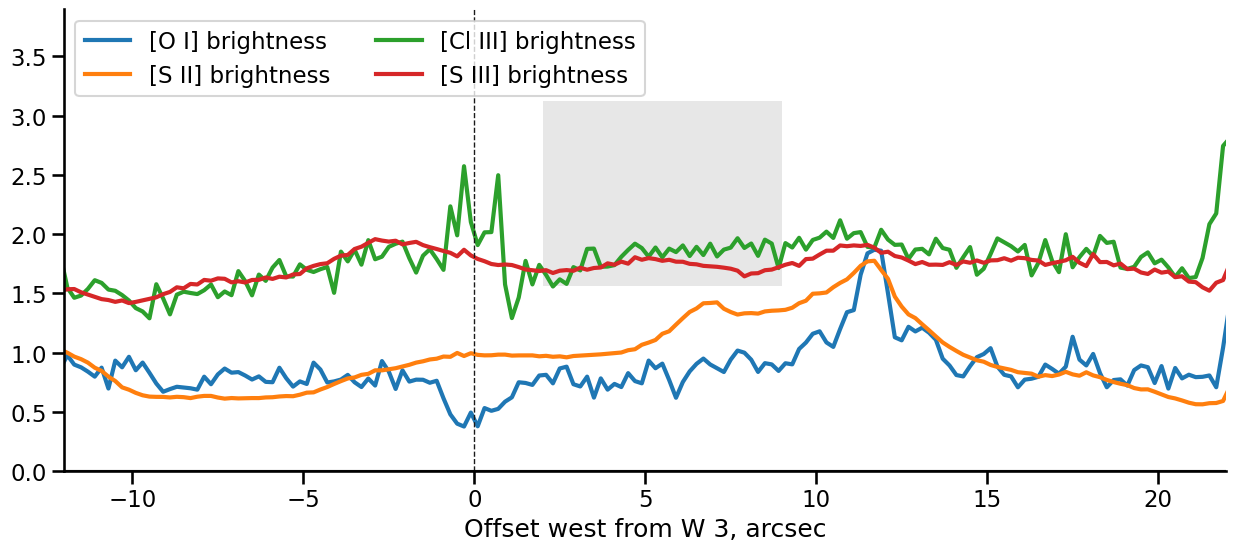

In [10]:
fig, ax = plt.subplots(figsize=(15, 6))
ix0 = 227.5
nx = len(oi_profile)
pos = (np.arange(nx) - ix0) * 0.2
pos2 = (np.arange(len(siil_profile)) - ix0) * 0.2

ax.plot(pos, 1.0 * oi_profile / np.median(oi_profile), label="[O I] brightness", lw=3)
ax.plot(
    pos2, 1.0 * sii_profile / np.median(sii_profile), label="[S II] brightness", lw=3
)
ax.plot(
    pos,
    1.7 * cliii_profile / np.median(cliii_profile),
    label="[Cl III] brightness",
    lw=3,
)
ax.plot(
    pos, 1.7 * siii_profile / np.median(siii_profile), label="[S III] brightness", lw=3
)


ax.axhline(0, color="k")

ax.axvline(0, color="k", lw=1, ls="dashed")
ax.axvspan(2.0, 9.0, 0.4, 0.8, color="k", alpha=0.1, linewidth=0, zorder=-100)
ax.legend(ncol=2, loc="upper left")

ax.set(
    xlabel="Offset west from W 3, arcsec",
    xlim=[-12, 22],
    ylim=[0, 3.9],
)
sns.despine()
fig.savefig(figdir / "ngc346-ZZ-bow-shock-lowion-cuts.pdf")